<center><h1>HOTEL BOOKING DEMAND</h1></center>

#### This dataset contain information of hotel booking, We will perform exploratory data analysis to get insight from the data.

##### We will try to answer the following Questions
* How Many Booking Were Cancelled?
* What is the booking ratio between Resort Hotel and City Hotel?
* What is the percentage of booking for each year?
* Which is the most busy month for hotel?
* From which country most guest come?
* How Long People Stay in the hotel?
* Which type of customers frequently book the hotel?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv("hotel_bookings.csv")
data.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
data.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [4]:
data.shape

(119390, 32)

In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### 1. Dealing with Missing Values

In [7]:
data.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [8]:
data.duplicated().sum()

31994

In [9]:
data.drop_duplicates(inplace=True)

In [10]:
data.duplicated().sum()

0

In [11]:
data['country'].unique()

array(['PRT', 'GBR', 'USA', 'ESP', 'IRL', 'FRA', nan, 'ROU', 'NOR', 'OMN',
       'ARG', 'POL', 'DEU', 'BEL', 'CHE', 'CN', 'GRC', 'ITA', 'NLD',
       'DNK', 'RUS', 'SWE', 'AUS', 'EST', 'CZE', 'BRA', 'FIN', 'MOZ',
       'BWA', 'LUX', 'SVN', 'ALB', 'IND', 'CHN', 'MEX', 'MAR', 'UKR',
       'SMR', 'LVA', 'PRI', 'SRB', 'CHL', 'AUT', 'BLR', 'LTU', 'TUR',
       'ZAF', 'AGO', 'ISR', 'CYM', 'ZMB', 'CPV', 'ZWE', 'DZA', 'KOR',
       'CRI', 'HUN', 'ARE', 'TUN', 'JAM', 'HRV', 'HKG', 'IRN', 'GEO',
       'AND', 'GIB', 'URY', 'JEY', 'CAF', 'CYP', 'COL', 'GGY', 'KWT',
       'NGA', 'MDV', 'VEN', 'SVK', 'FJI', 'KAZ', 'PAK', 'IDN', 'LBN',
       'PHL', 'SEN', 'SYC', 'AZE', 'BHR', 'NZL', 'THA', 'DOM', 'MKD',
       'MYS', 'ARM', 'JPN', 'LKA', 'CUB', 'CMR', 'BIH', 'MUS', 'COM',
       'SUR', 'UGA', 'BGR', 'CIV', 'JOR', 'SYR', 'SGP', 'BDI', 'SAU',
       'VNM', 'PLW', 'QAT', 'EGY', 'PER', 'MLT', 'MWI', 'ECU', 'MDG',
       'ISL', 'UZB', 'NPL', 'BHS', 'MAC', 'TGO', 'TWN', 'DJI', 'STP',
       'KNA', 'E

In [12]:
data['country'].fillna(data.country.mode().to_string(), inplace=True)

In [13]:
data.isnull().sum()

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
meal                                  0
country                               0
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                             12193
company                           82137


In [14]:
data['agent'].fillna("Unknown",inplace=True)

In [15]:
data['company'].value_counts()

company
40.0     851
223.0    503
45.0     238
153.0    206
154.0    133
        ... 
10.0       1
419.0      1
415.0      1
425.0      1
534.0      1
Name: count, Length: 352, dtype: int64

In [16]:
data.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [17]:
data['company'].fillna(0,inplace=True)

In [18]:
data['company'].unique()

array([  0., 110., 113., 270., 178., 240., 154., 144., 307., 268.,  59.,
       204., 312., 318.,  94., 174., 274., 195., 223., 317., 281., 118.,
        53., 286.,  12.,  47., 324., 342., 373., 371., 383.,  86.,  82.,
       218.,  88.,  31., 397., 392., 405., 331., 367.,  20.,  83., 416.,
        51., 395., 102.,  34.,  84., 360., 394., 457., 382., 461., 478.,
       386., 112., 486., 421.,   9., 308., 135., 224., 504., 269., 356.,
       498., 390., 513., 203., 263., 477., 521., 169., 515., 445., 337.,
       251., 428., 292., 388., 130., 250., 355., 254., 543., 531., 528.,
        62., 120.,  42.,  81., 116., 530., 103.,  39.,  16.,  92.,  61.,
       501., 165., 291., 290.,  43., 325., 192., 108., 200., 465., 287.,
       297., 490., 482., 207., 282., 437., 225., 329., 272.,  28.,  77.,
       338.,  72., 246., 319., 146., 159., 380., 323., 511., 407., 278.,
        80., 403., 399.,  14., 137., 343., 346., 347., 349., 289., 351.,
       353.,  54.,  99., 358., 361., 362., 366., 37

In [19]:
data['children'].unique()

array([ 0.,  1.,  2., 10.,  3., nan])

In [20]:
data['children'].fillna(round(data.children.mean()), inplace=True)

In [21]:
data = data.drop(data[(data.adults+data.babies+data.children)==0].index)

In [22]:
data.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [23]:
data['agent'].unique()

array(['Unknown', 304.0, 240.0, 303.0, 15.0, 241.0, 8.0, 250.0, 115.0,
       5.0, 175.0, 134.0, 156.0, 243.0, 242.0, 3.0, 105.0, 40.0, 147.0,
       306.0, 184.0, 96.0, 2.0, 127.0, 95.0, 146.0, 9.0, 177.0, 6.0,
       143.0, 244.0, 149.0, 167.0, 300.0, 171.0, 305.0, 67.0, 196.0,
       152.0, 142.0, 261.0, 104.0, 36.0, 26.0, 29.0, 258.0, 110.0, 71.0,
       181.0, 88.0, 251.0, 275.0, 69.0, 248.0, 208.0, 256.0, 314.0, 126.0,
       281.0, 273.0, 253.0, 185.0, 330.0, 334.0, 328.0, 326.0, 321.0,
       324.0, 313.0, 38.0, 155.0, 68.0, 335.0, 308.0, 332.0, 94.0, 348.0,
       310.0, 339.0, 375.0, 66.0, 327.0, 387.0, 298.0, 91.0, 245.0, 385.0,
       257.0, 393.0, 168.0, 405.0, 249.0, 315.0, 75.0, 128.0, 307.0, 11.0,
       436.0, 1.0, 201.0, 183.0, 223.0, 368.0, 336.0, 291.0, 464.0, 411.0,
       481.0, 10.0, 154.0, 468.0, 410.0, 390.0, 440.0, 495.0, 492.0,
       493.0, 434.0, 57.0, 531.0, 420.0, 483.0, 526.0, 472.0, 429.0, 16.0,
       446.0, 34.0, 78.0, 139.0, 252.0, 270.0, 47.0, 114.0

In [24]:
data['meal'].unique()

array(['BB', 'FB', 'HB', 'SC', 'Undefined'], dtype=object)

### 2. Converting Datatype

In [25]:
data[['children', 'company']] = data[['children', 'company']].astype('int64')

### 3. Correlation matrix of numerical values

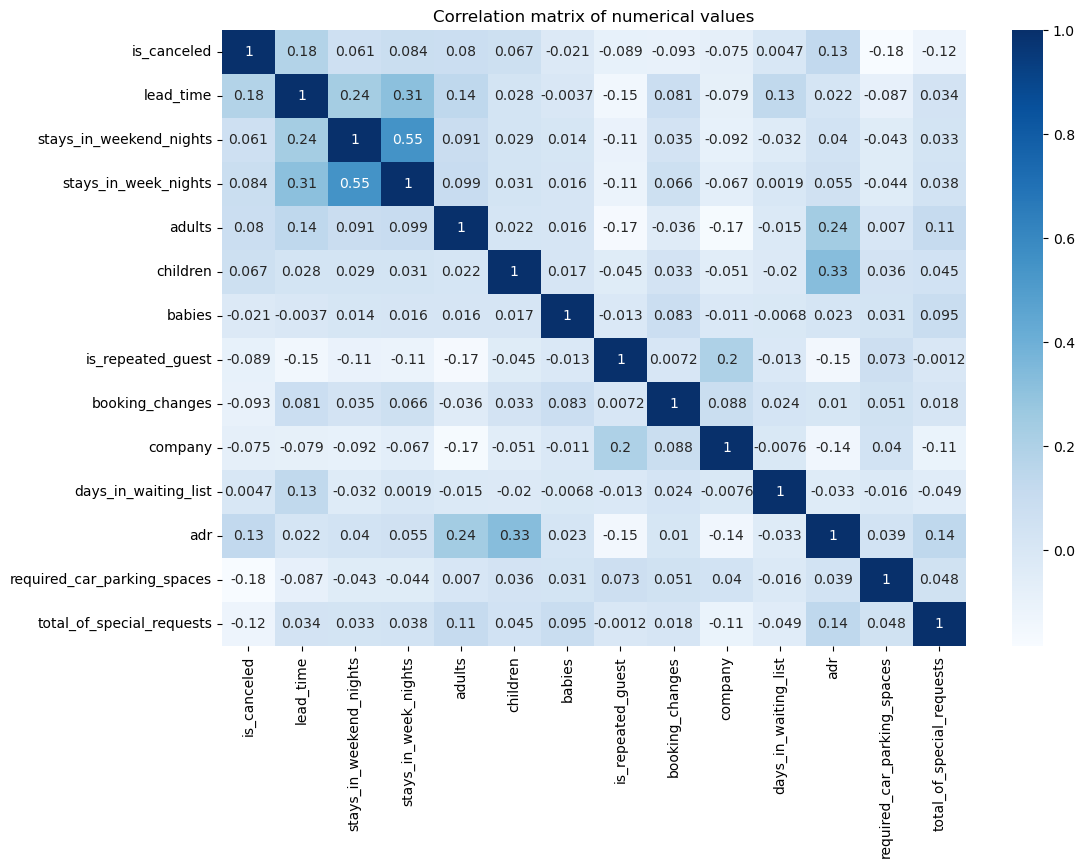

In [37]:
corr_hotel=data[[ 'is_canceled', 'lead_time', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 
       'is_repeated_guest', 
        'booking_changes', 
       'company', 'days_in_waiting_list',  'adr',
       'required_car_parking_spaces', 'total_of_special_requests'
       ]].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_hotel,annot=True,cbar=True,cmap='Blues')
plt.title("Correlation matrix of numerical values")
plt.show()

* There is no significant correlation between numerical values 

### 4.Exploratory Data Analysis

#### Trend in booking cancellation

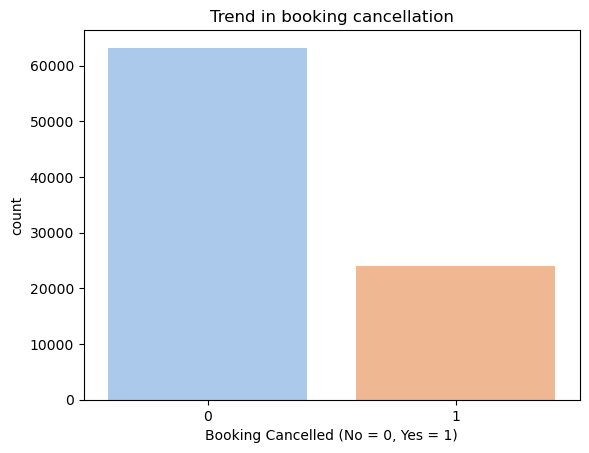

In [38]:
sns.countplot(data=data,x='is_canceled',palette='pastel')
plt.xlabel("Booking Cancelled (No = 0, Yes = 1)")
plt.title("Trend in booking cancellation")
plt.show()

* Most of the bookings were not cancelled. so for further verification only this non cancelled details is considered

#### booking ratio between Resort Hotel and City Hotel

In [27]:
data_not_calcelled=data[data['is_canceled']==0]

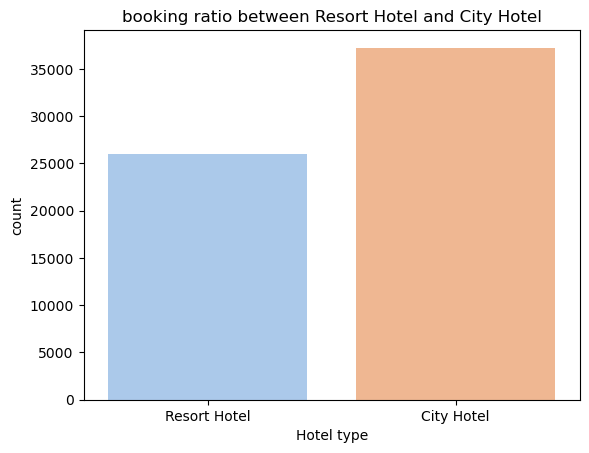

In [40]:
sns.countplot(data=data_not_calcelled,x='hotel',palette='pastel')
plt.title("booking ratio between Resort Hotel and City Hotel")
plt.xlabel("Hotel type")
plt.show()

* Most of the people pefer city hotels.
* There is no huge difference between resort hotel and city hotel

### Booking for each year

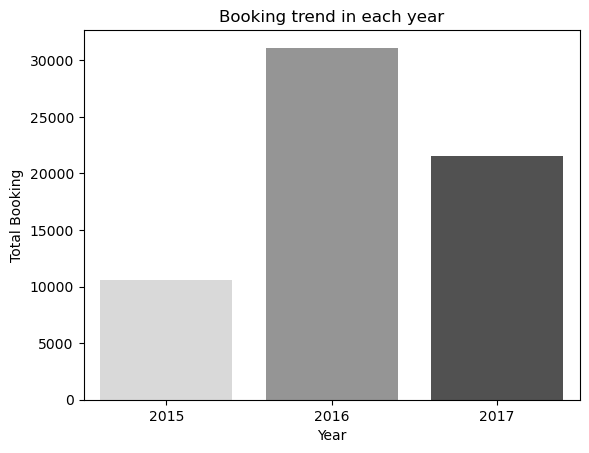

In [42]:
sns.countplot(data=data_not_calcelled,x='arrival_date_year',palette='Greys')
plt.xlabel("Year")
plt.ylabel("Total Booking")
plt.title("Booking trend in each year")
plt.show()

* 2016 had the highest overall bookings
* Booking numbers rose from 2015 to 2016, then dropped slightly in 2017, indicating a potential peak in popularity or availability in 2016. 

### Monthly booking trends

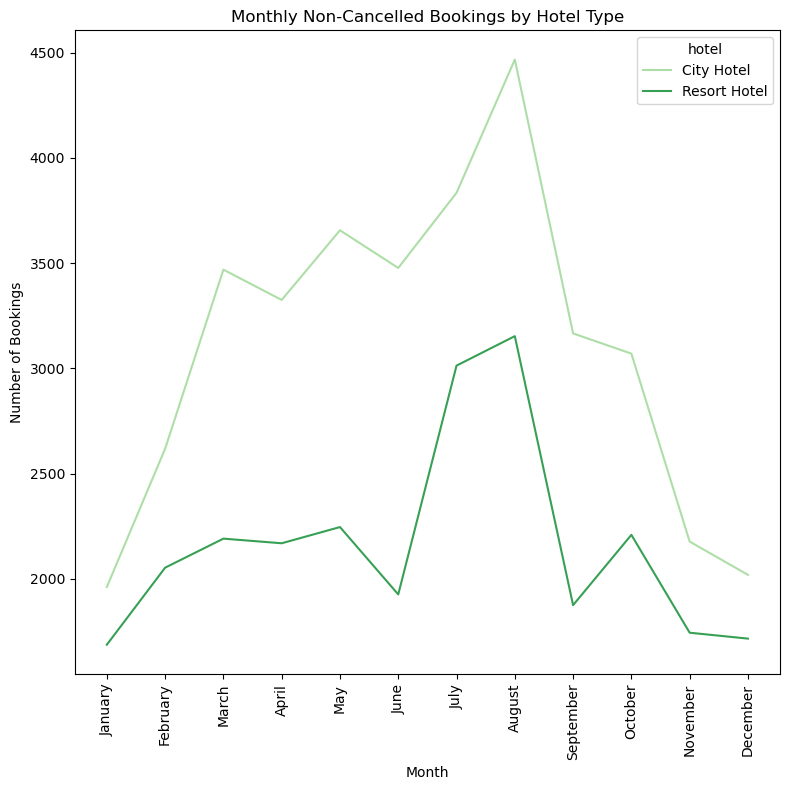

In [30]:
monthly_counts = data_not_calcelled.groupby(['arrival_date_month', 'hotel']).size().reset_index(name='count')
month_order = ['January', 'February', 'March', 'April', 'May', 'June','July', 'August', 'September', 'October', 'November', 'December']
monthly_counts['arrival_date_month'] = pd.Categorical(monthly_counts['arrival_date_month'], categories=month_order, ordered=True)
monthly_counts.sort_values('arrival_date_month', inplace=True)

# Plot
plt.figure(figsize=(8, 8))
sns.lineplot(data=monthly_counts, x='arrival_date_month', y='count', hue='hotel', palette='Greens')
plt.title('Monthly Non-Cancelled Bookings by Hotel Type')
plt.xticks(rotation=90)
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.tight_layout()
plt.show()

* City Hotel bookings are consistently higher across most months, especially in May to October, peaking in August.
* Resort Hotel bookings show a strong seasonal pattern, peaking in July and August, likely due to summer vacations.
* January to March have the lowest booking numbers for both hotel types, suggesting off-season or less travel activity.

### Distribution of stay durations

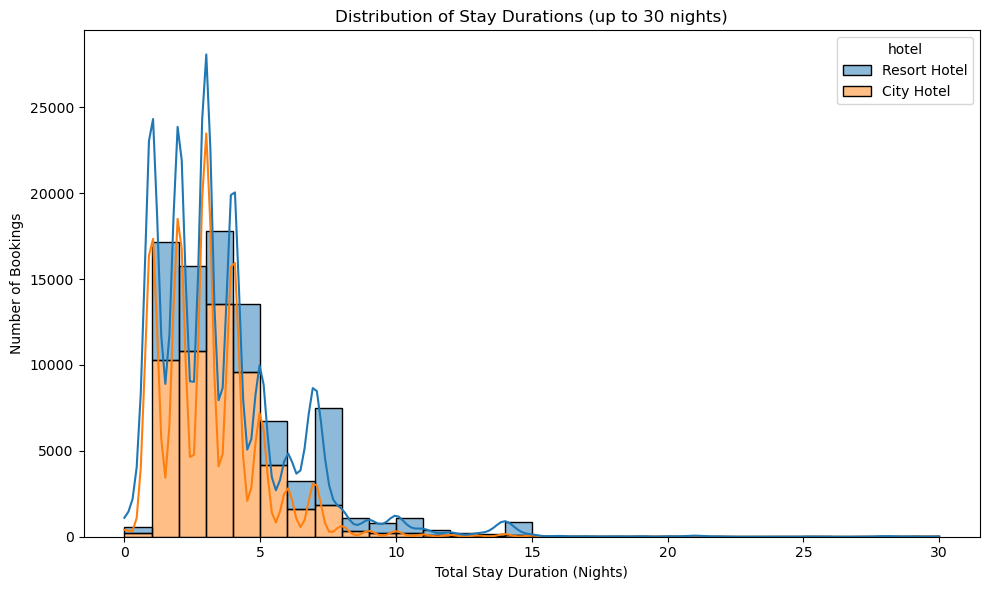

In [31]:

data['total_stay'] = data['stays_in_weekend_nights'] + data['stays_in_week_nights']

# Filter out long stays for cleaner plot
filtered_stays = data[data['total_stay'] <= 30]

# Plotting
plt.figure(figsize=(10, 6))
sns.histplot(data=filtered_stays, x='total_stay', hue='hotel', multiple='stack', bins=30, kde=True)
plt.title('Distribution of Stay Durations (up to 30 nights)')
plt.xlabel('Total Stay Duration (Nights)')
plt.ylabel('Number of Bookings')
plt.tight_layout()
plt.show()

* Most stays are short: The majority of bookings are for 1 to 3 nights.
* City Hotels likely have more 1–2 night stays, catering to business or quick trips.
* Resort Hotels show a broader range of stay durations, often peaking around 7 nights, consistent with vacation trips.
* A small number of stays exceed 2 weeks, possibly due to long vacations or special arrangements.

### Bookings by customer type

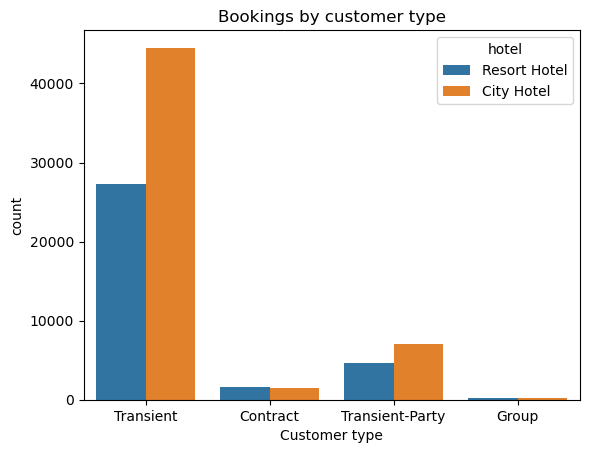

In [43]:
sns.countplot(data=data,x='customer_type',hue='hotel')
plt.xlabel("Customer type")
plt.title("Bookings by customer type")
plt.show()

* Transient customers are the most common — these are individual travelers not part of a group.
* Transient-party and Contract bookings are typically less frequent.


### Bookings by country of customers

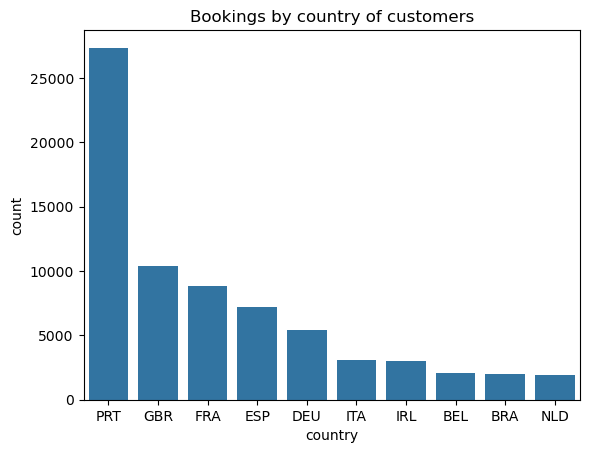

In [44]:
df=data['country'].value_counts().head(10).reset_index()
df.columns = ['country', 'count']
sns.barplot(data=df,x='country', y='count')
plt.title("Bookings by country of customers")
plt.show()

* most of the customers are from portugal.
* There is significant number of customers from  UK,france,spain and germany

#### Trend in repeated booking

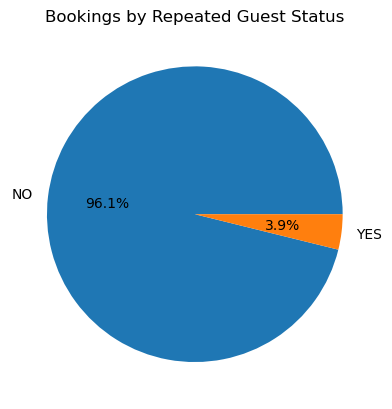

In [58]:
repeated_count=data['is_repeated_guest'].value_counts()
plt.pie(repeated_count,labels=['NO','YES'],autopct="%1.1f%%")
#sns.countplot(data=data,x=data['is_repeated_guest'])
plt.title('Bookings by Repeated Guest Status')
plt.show()

* The vast majority will be new guests, as typically seen in hotel booking datasets.
* Repeated guests will be a small portion.

### Conclusion

* Most of the people pefer city hotels.
* There is no huge difference between resort hotel and city hotel
* Most of the bookings were not cancelled.
* 2016 had the highest overall bookings
* Booking numbers rose from 2015 to 2016, then dropped slightly in 2017, indicating a potential peak in popularity or availability in 2016.
* City Hotel bookings are consistently higher across most months, especially in May to October, peaking in August.
* Resort Hotel bookings show a strong seasonal pattern, peaking in July and August, likely due to summer vacations.
* January to March have the lowest booking numbers for both hotel types, suggesting off-season or less travel activity.
* Most stays are short: The majority of bookings are for 1 to 3 nights.
* City Hotels likely have more 1–2 night stays, catering to business or quick trips.
* Resort Hotels show a broader range of stay durations, often peaking around 7 nights, consistent with vacation trips.
* A small number of stays exceed 2 weeks, possibly due to long vacations or special arrangements.
* Transient customers are the most common — these are individual travelers not part of a group.
* Transient-party and Contract bookings are typically less frequent.
* most of the customers are from portugal.
* There is significant number of customers from UK,france,spain and germany
* The vast majority will be new guests, as typically seen in hotel booking datasets.Repeated guests will be a small portion.